# Task 1: Building and training a denoising autoencoder using MNIST Handwritten Dataset

## Load and Preprocess MNIST Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to add channel dimension (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## Add Gaussian Noise to Images

In [ ]:
# Add Gaussian noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully!")

Noise added successfully!


## Visualize Original vs Noisy Images

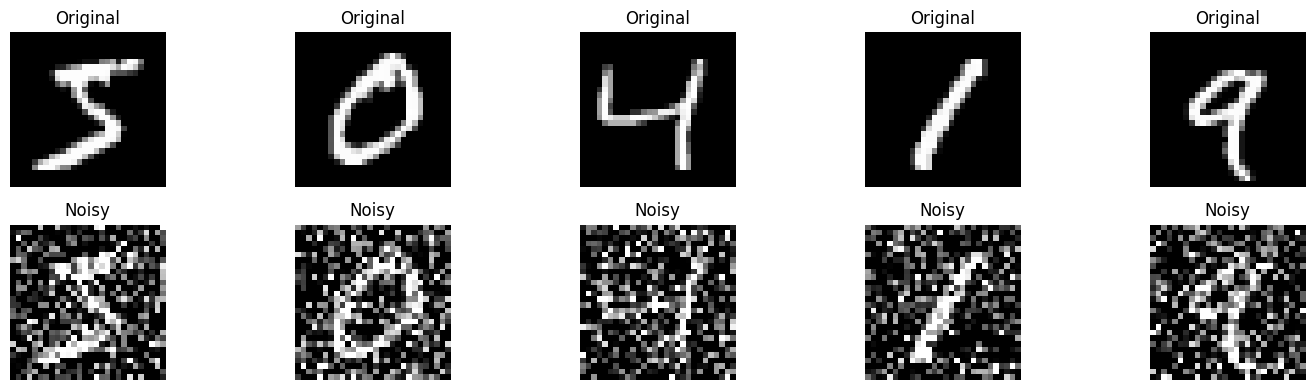

In [ ]:
# Display original and noisy images
n = 5  # number of images to display
plt.figure(figsize=(15, 4))

for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Build the Convolutional Autoencoder

In [ ]:
# Encoder
input_img = Input(shape=(28, 28, 1), name="input")

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

# Create autoencoder model
autoencoder = Model(inputs=input_img, outputs=decoded, name="autoencoder")

# Compile the model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# Display model summary
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Autoencoder

In [ ]:
# Train the model
history = autoencoder.fit(
    x_train_noisy,  # input: noisy images
    x_train,        # target: clean images
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 390ms/step - loss: 0.1467 - val_loss: 0.1104
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 395ms/step - loss: 0.1082 - val_loss: 0.1041
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 177s 377ms/step - loss: 0.1037 - val_loss: 0.1014
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 375ms/step - loss: 0.1014 - val_loss: 0.0995
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 364ms/step - loss: 0.0999 - val_loss: 0.0983
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 372ms/step - loss: 0.0987 - val_loss: 0.0982
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 365ms/step - loss: 0.0978 - val_loss: 0.0967
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 372ms/step - loss: 0.0970 - val_loss: 0.0961
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 365ms/step - loss: 0.0964 - val_loss: 0.0954
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 361ms/step - loss: 0.0958 - val_loss: 0.0950
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 369ms/step - loss: 0.0954 - val_loss: 0.0949
Epoch 12

## Plot Training Loss

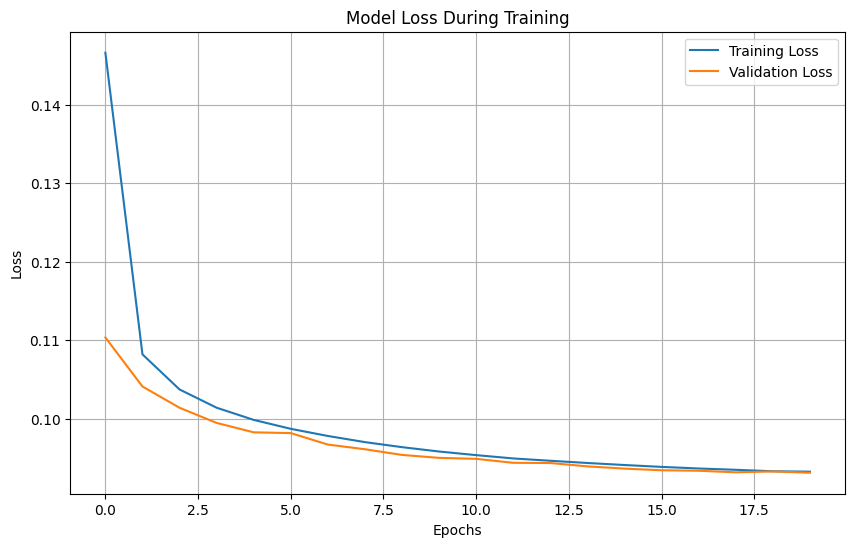

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Visualize Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


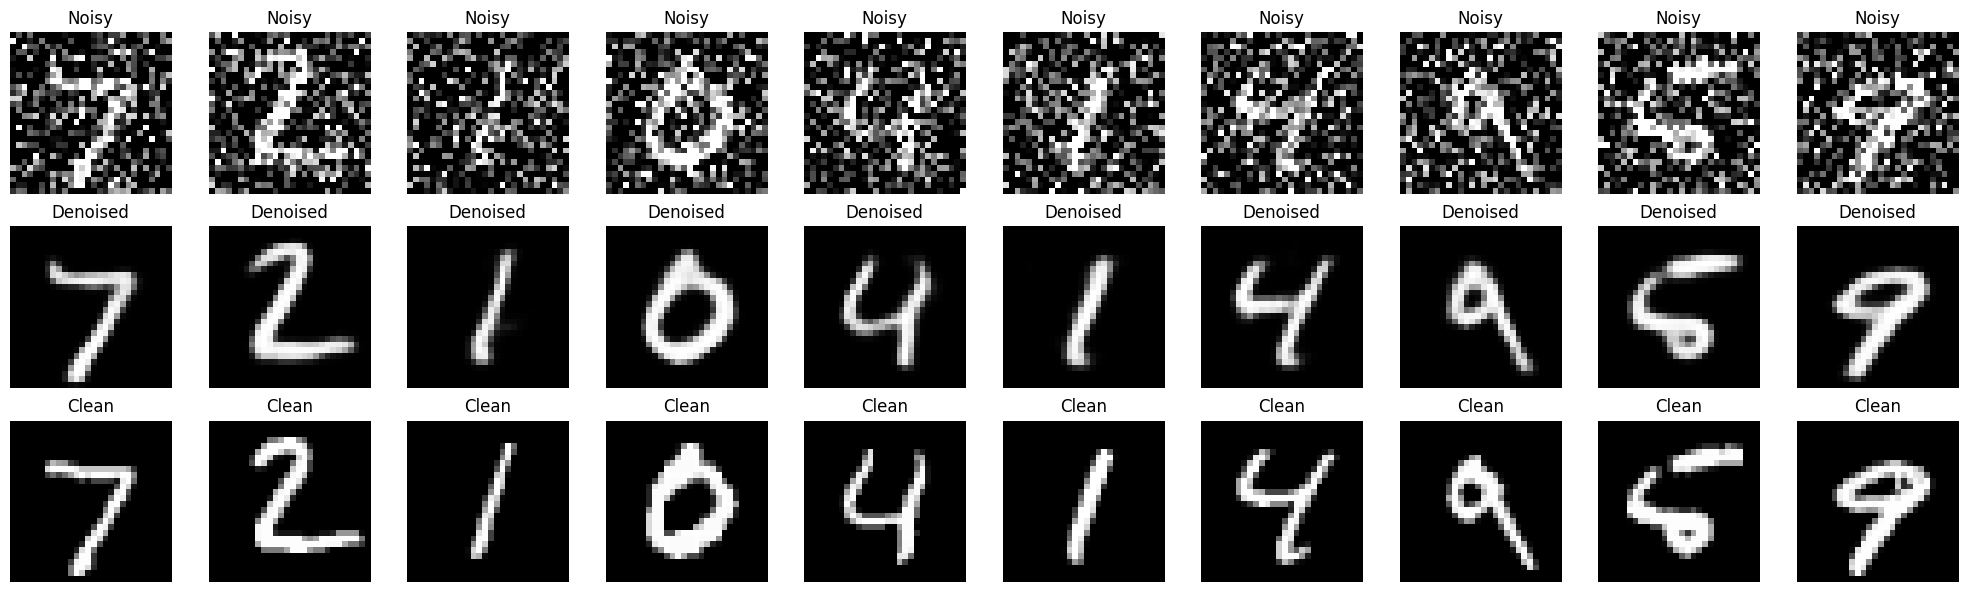

In [ ]:
# Predict denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy)

# Function to display images
def plot_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy images (top row)
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised images (middle row)
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean images (bottom row)
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display results for first 10 test images
plot_results(x_test_noisy, denoised_images, x_test, n=10)

## Test with Different Noise Levels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


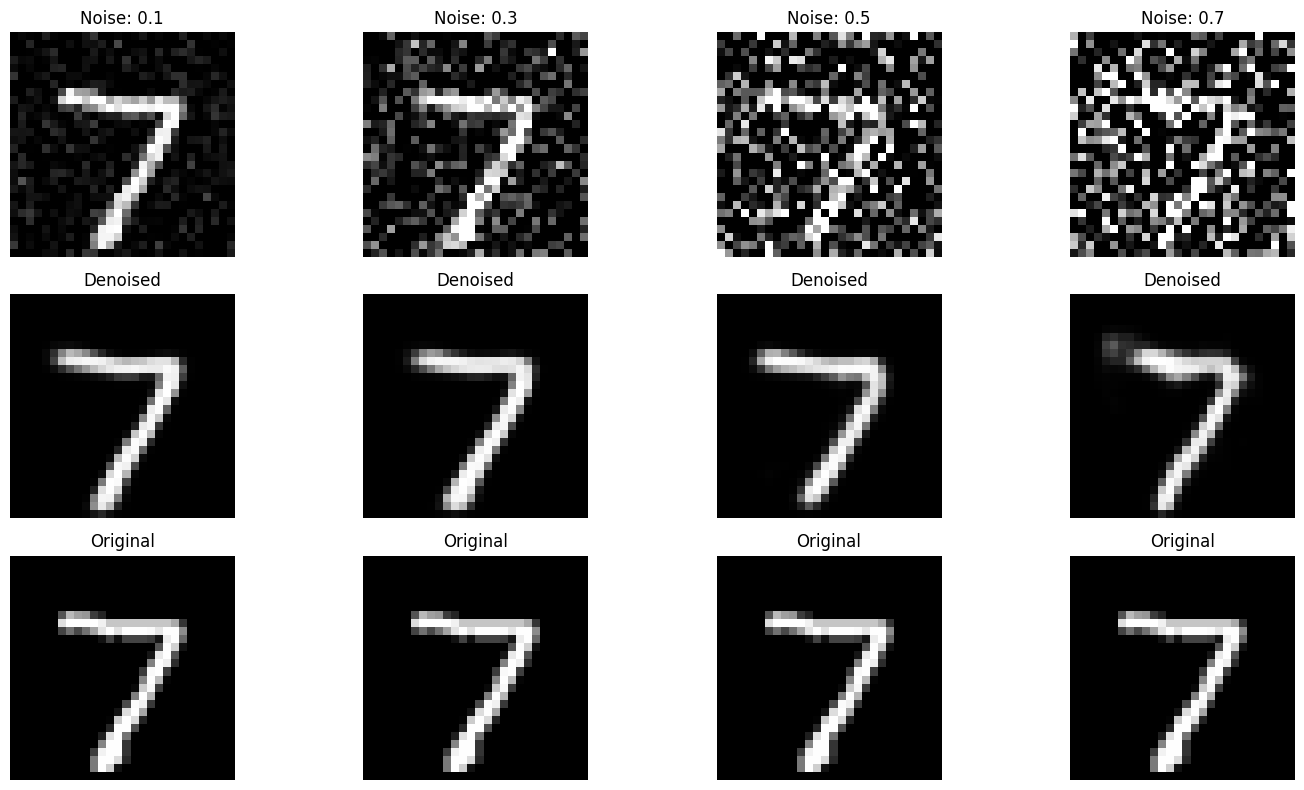

In [ ]:
noise_factors = [0.1, 0.3, 0.5, 0.7]

plt.figure(figsize=(15, 8))

for idx, noise_factor in enumerate(noise_factors):
    # Add noise to a single test image
    sample_image = x_test[0:1]
    noisy_sample = sample_image + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=sample_image.shape)
    noisy_sample = np.clip(noisy_sample, 0., 1.)

    # Denoise
    denoised_sample = autoencoder.predict(noisy_sample)

    # Display
    plt.subplot(3, len(noise_factors), idx + 1)
    plt.imshow(noisy_sample[0].reshape(28, 28), cmap='gray')
    plt.title(f"Noise: {noise_factor}")
    plt.axis('off')

    plt.subplot(3, len(noise_factors), idx + 1 + len(noise_factors))
    plt.imshow(denoised_sample[0].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(3, len(noise_factors), idx + 1 + 2*len(noise_factors))
    plt.imshow(sample_image[0].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Task 2: Build a Denoising Convolutional Autoencoder using Devnagari Handwritten Digit Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Devnagari Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import random

train_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Train/"
test_dir = "/content/drive/MyDrive/6S012 Artificial Intelligence/Workshop/Week-4/dataset/Test/"

def load_images(folder_path, img_size=(28, 28)):

    images = []
    labels = []
    class_names = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            class_names.append(class_name)
            for img_file in os.listdir(class_path):
                if img_file.endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        # Load image using PIL
                        img = Image.open(img_path)
                        # Convert to grayscale
                        img = img.convert('L')
                        # Resize to 28x28
                        img = img.resize(img_size)
                        # Convert to numpy array and normalize
                        img_array = np.array(img) / 255.0
                        images.append(img_array)
                        labels.append(class_name)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels), class_names

x_train_raw, y_train_raw, train_classes = load_images(train_dir)

x_test_raw, y_test_raw, test_classes = load_images(test_dir)

print(f"\nTraining images loaded: {x_train_raw.shape}")
print(f"Test images loaded: {x_test_raw.shape}")
print(f"Classes found: {train_classes}")


## Preprocess and Prepare Data

In [ ]:
# Reshape to add channel dimension (28, 28, 1)
x_train = x_train_raw.reshape(-1, 28, 28, 1)
x_test = x_test_raw.reshape(-1, 28, 28, 1)

# Split training data into train and validation sets (80% train, 20% validation)
x_train_split, x_val_split = train_test_split(x_train, test_size=0.2, random_state=42)

print(f"Training set shape: {x_train_split.shape}")
print(f"Validation set shape: {x_val_split.shape}")
print(f"Test set shape: {x_test.shape}")

# Display sample images
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train_split[i].reshape(28, 28), cmap='gray')
    plt.title(f"Sample {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Add Gaussian Noise to Images

In [ ]:
# Add Gaussian noise
noise_factor = 0.3

# Add noise to training set
x_train_noisy = x_train_split + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_split.shape)

# Add noise to validation set
x_val_noisy = x_val_split + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val_split.shape)

# Add noise to test set
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise added successfully!")

# Visualize original vs noisy
n = 5
plt.figure(figsize=(15, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(x_train_split[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2, n, i+1+n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title(f"Noisy (factor={noise_factor})")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Build Deep Convolutional Autoencoder

In [ ]:
def build_deep_autoencoder(input_shape=(28, 28, 1)):

    # ENCODER (4 convolutional layers + pooling)
    input_img = Input(shape=input_shape, name="input")

    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14

    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7

    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

    # Layer 4 (bottleneck)
    encoded = Conv2D(256, (3, 3), activation='relu', padding='same', name="encoded")(x)
    # 4x4x256 = latent representation

    # DECODER (4 convolutional layers + upsampling)
    # Layer 5
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)  # 8x8

    # Layer 6
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 16x16

    # Layer 7
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 32x32

    # Layer 8 (final output)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    # Create model
    autoencoder = Model(inputs=input_img, outputs=decoded, name="deep_autoencoder")

    return autoencoder

# Build the model
autoencoder = build_deep_autoencoder()
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

# Display model architecture
autoencoder.summary()

## Train the Autoencoder

In [ ]:
# Train the model
history = autoencoder.fit(
    x_train_noisy,  # Input: noisy images
    x_train_split,  # Target: clean images
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_val_noisy, x_val_split),
    verbose=1
)

## Plot Training & Validation Loss

In [ ]:
# Plot loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)

# Plot loss on log scale
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Loss (Log Scale)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final loss values
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

## Visualize Results

In [ ]:
# Predict denoised images from noisy test images
print("Predicting denoised images...")
denoised_images = autoencoder.predict(x_test_noisy, verbose=1)

# Function to display results
def plot_denoising_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 8))

    for i in range(n):
        # Noisy images (top row)
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        if i == 0:
            plt.title("Noisy Input", fontsize=12)
        plt.axis('off')

        # Denoised images (middle row)
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        if i == 0:
            plt.title("Denoised Output", fontsize=12)
        plt.axis('off')

        # Clean images (bottom row)
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        if i == 0:
            plt.title("Original Clean", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display results for first 10 test images
plot_denoising_results(x_test_noisy, denoised_images, x_test, n=10)

## Experiment with Different Noise Levels

In [ ]:
noise_factors = [0.1, 0.3, 0.5, 0.7]

# Pick a single test image
sample_idx = 0
sample_clean = x_test[sample_idx:sample_idx+1]

plt.figure(figsize=(16, 10))

for idx, noise_factor in enumerate(noise_factors):
    # Add noise with different levels
    sample_noisy = sample_clean + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=sample_clean.shape)
    sample_noisy = np.clip(sample_noisy, 0., 1.)

    # Denoise
    sample_denoised = autoencoder.predict(sample_noisy, verbose=0)

    # Display
    plt.subplot(4, 3, idx*3 + 1)
    plt.imshow(sample_noisy[0].reshape(28, 28), cmap='gray')
    plt.title(f"Noise Factor: {noise_factor}")
    plt.axis('off')

    plt.subplot(4, 3, idx*3 + 2)
    plt.imshow(sample_denoised[0].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(4, 3, idx*3 + 3)
    plt.imshow(sample_clean[0].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Experiment with Different Model Architectures

In [ ]:
def build_autoencoder_v2(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    return Model(inputs=input_img, outputs=decoded)

# Test alternative architecture
autoencoder_v2 = build_autoencoder_v2()
autoencoder_v2.compile(optimizer=Adam(), loss='binary_crossentropy')
autoencoder_v2.summary()

In [ ]:
# Save the trained model
autoencoder.save('/content/drive/MyDrive/6S012 Artificial Intelligence/devnagari_denoising_autoencoder.h5')
print("Model saved successfully!")